# Phase 1: Week 5 - Python Meets SQL In-class Demonstrations

## Create and Drop a Table
We’ll create two tables: a users table (with ID, Name, and Email columns) and a shop table (with ID, Name, and Owner columns). After creating them, we’ll practice deleting the users table using the DROP command.
To do this, we are going to:
1. Open VSCode with the SQLTools extension ready
2. Completing each query at a time, write the SQL commands to:
    1. Create the table
    2. Drop the table

We will use the SQLTools extension to run queries and see SQL in action.


In [ ]:
-- Create a table called 'users' with columns 'id', 'name', and 'email'
CREATE TABLE users (
  id INTEGER PRIMARY KEY,
  name TEXT,
  email TEXT UNIQUE
);

-- Create a table called 'shop' with columns 'id', 'name', 'owner'
CREATE TABLE shop (
  id INTEGER PRIMARY KEY,
  name TEXT,
  owner TEXT
);

-- Drops the users 'table'
DROP TABLE users;

3. With VSCode open, ensure your database is connected in the SQLTools extensions and the connection is ON.
    1. You will know the connection is **ON** when the light indicator on the table is green, while the plug icon has been split in two and is red.
    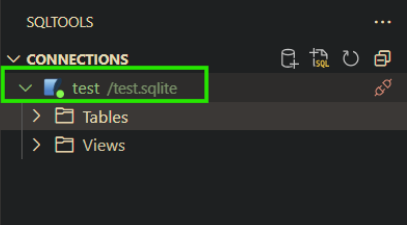

    2. You will know the connection is **OFF** when the light indicator is not present, while the plug icon is singular and also green.
    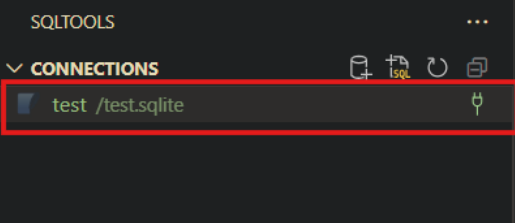

4. Paste this code into your test.session.sql file to create two (2) tables: `users` and `shop`

In [ ]:
-- Create a table called 'users' with columns 'id', 'name', and 'email'
CREATE TABLE users (
  id INTEGER PRIMARY KEY,
  name TEXT,
  email TEXT UNIQUE
);

-- Create a table called 'shop' with columns 'id', 'name', 'owner'
CREATE TABLE shop (
  id INTEGER PRIMARY KEY,
  name TEXT,
  owner TEXT
);

4. Click `Run on active connection` in your `test.session.sql` file to send the query to your database

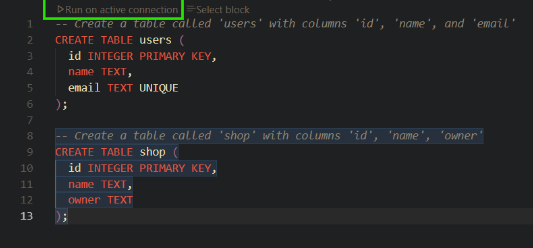

If successful, a window with two (2) tabs should open to indicate each query has been made effectively.

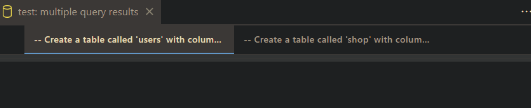

5. Right-click on your database title and click `Refresh`.

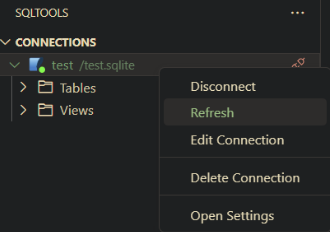

If successful, you should see your new tables.

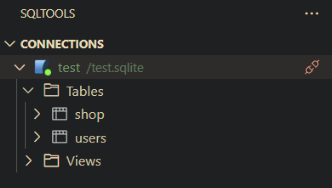

6. Paste this code into your `test.session.sql` file to delete two (2) tables: `users` and `shop`.
    1. Run the connection
    2. Refresh your database and ensure the tables have been deleted

In [ ]:
-- Drops the users 'table'
DROP TABLE users;
-- Drops the shop 'table'
DROP TABLE shop;

### End of Create and Drop Table

Continue with the slides

## Inserting and Selecting From a Table

1. Using SQLTools, add two new rows of data into the `shop` table
    1. `('Grocery Mart', 'John Doe')`
    2. `('Vegetable Stand', 'Jane Smith')`

In [ ]:
INSERT INTO shop (name, owner)
VALUES
   ('Grocery Mart', 'John Doe'),
   ('Vegetable Stand', 'Jane Smith');

2. Select all the `shops`

In [ ]:
SELECT * FROM shop;

3. Select one shop where the name is “Vegetable Stand”

In [ ]:
SELECT * FROM shop WHERE name = 'Vegetable Shop';

### End of Inserting and Selecting From a Table

Continue with the slides

## Updating and Deleting a Table

1. Update the “Grocery Mart” shop name to be “Mi Gente Deli Grocery” in the shop table:
    1. Use the UPDATE Statement on the table (shop)
2. Use the SET Statement on the column you want to edit along with the value you want to change to
3. Use the WHERE clause to say which row (or rows) you want this update to affect

In [ ]:
UPDATE shop
SET name = "Mi Gente Deli Grocery"
WHERE id = 2;

4. Delete the “Mi Gente Deli Grocery” in the shop table:
    1. Use the DELETE statement. We are only going to delete ONE shop.

In [ ]:
DELETE FROM shop WHERE id = 2;

### End of Updating and Deleting a Table

Continue with the slides

## One to One Relationship (Schema)

The database is going to have two tables: `users` and `shop`.

The `users` table stores information about customers, such as their `ID`, `name`, and `email`. The `shop` table stores information about shops, like their `ID`, `name`, and `owner`.

To create a one-to-one relationship, you need to connect them so that:

* One user owns exactly one shop.
* One shop is owned by exactly one user.

To do this you need to add a Foreign Key to the Shop Table so that:
1. The `shop` table gets a new column (`owner_id`) that references a `user`'s `ID`.
2. The `UNIQUE` constraint ensures no two shops can have the same `owner` value.

In [ ]:
-- Users table
CREATE TABLE users (
 id INT PRIMARY KEY,
 name VARCHAR(100),
 email VARCHAR(150) UNIQUE
);

-- Shop table with owner reference
CREATE TABLE shop (
 id INT PRIMARY KEY,
 name VARCHAR(100),
 owner_id INT UNIQUE,
 FOREIGN KEY (owner_id) REFERENCES users(id)
);

The query below is known as a `JOIN` query. 

In [ ]:
JOIN
   users u ON s.owner_id = u.id;

A `JOIN` query combines rows from two or more tables based on a related column (like a foreign key), letting you retrieve data from multiple tables in a single result. 

It acts like a bridge—matching records that share a connection (e.g., linking a shop to its owner from the users table)—so you can see unified data instead of isolated fragments.

In [ ]:
SELECT
   s.id AS shop_id,
   s.name AS shop_name,
   u.id AS owner_id,
   u.name AS owner_name,
   u.email AS owner_email
FROM
   shop s
JOIN
   users u ON s.owner_id = u.id;

The query above joins the `shop` table (`s`) with `users` (`u`) where `shop.owner_id` matches `users.id`.
It returns:
* Shop details (id, name)
* Owner details (id, name, email from the users table)

### End of One to One Relationships

Continue with the slides

## One to Many Relationships (Schema)

The database has three tables:
* `users`
* `shops` (the "one" side)
* `products` (the "many" side)

In [ ]:
-- Users table
CREATE TABLE users (
 id INT PRIMARY KEY,
 name VARCHAR(100),
 email VARCHAR(150) UNIQUE
);

-- Shop table with owner reference
CREATE TABLE shop (
 id INT PRIMARY KEY,
 name VARCHAR(100),
 owner_id INT UNIQUE,
 FOREIGN KEY (owner_id) REFERENCES users(id)
);

-- Products table (the "many" side)
CREATE TABLE products (
 id INT PRIMARY KEY,
 name VARCHAR(100),
 price DECIMAL(10,2),
);

The One to Many relationship means:
* One shop can sell many products
* Each product belongs to only one shop

The difference between the One to One and One to Many is there are No `UNIQUE` constraints on the foreign key (many products can reference one shop)

In [ ]:
SELECT
   p.id AS product_id,
   p.name AS product_name,
   p.price,
   s.name AS shop_name,
   u.name AS owner_name
FROM
   products p
JOIN
   shop s ON p.shop_id = s.id
JOIN
   users u ON s.owner_id = u.id
WHERE s.id = 2;

This query has 2 JOINs (one for the shop and one for the owner)
* First `JOIN`: Connects each product to its shop (`products.shop_id` → `shop.id`)
* Second `JOIN`: Connects each shop to its owner (`shop.owner_id` → `users.id`)

This query returns:
* Product details (`ID`, `name`, `price`)
* Shop `name`
* Shop owner's `name`


In [ ]:
### End of One to Many Relationships

Continue with the slides